In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/processed/SWaT_cleaned.csv")

In [3]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 494986


In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Shape after removing duplicates: (946733, 46)
Remaining duplicates: 0


In [5]:
df["Normal/Attack"].value_counts()

Normal/Attack
0    892112
1     54621
Name: count, dtype: int64

In [6]:
df.to_csv("../data/processed/SWaT_cleaned.csv", index=False)

In [7]:
X = df.drop(columns=["Normal/Attack", "Timestamp"])
y = df["Normal/Attack"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
#test 
print("Train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Train:
Normal/Attack
0    713689
1     43697
Name: count, dtype: int64
Normal/Attack
0    94.230551
1     5.769449
Name: proportion, dtype: float64

Test:
Normal/Attack
0    178423
1     10924
Name: count, dtype: int64
Normal/Attack
0    94.230698
1     5.769302
Name: proportion, dtype: float64


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(757386, 44)
(189347, 44)


In [12]:
baseline_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

baseline_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [13]:
y_pred = baseline_model.predict(X_test_scaled)

In [14]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96    178423
           1       0.43      0.82      0.57     10924

    accuracy                           0.93    189347
   macro avg       0.71      0.88      0.76    189347
weighted avg       0.96      0.93      0.94    189347



Logistic Regression:
[[166559  11864]
 [  1930   8994]]


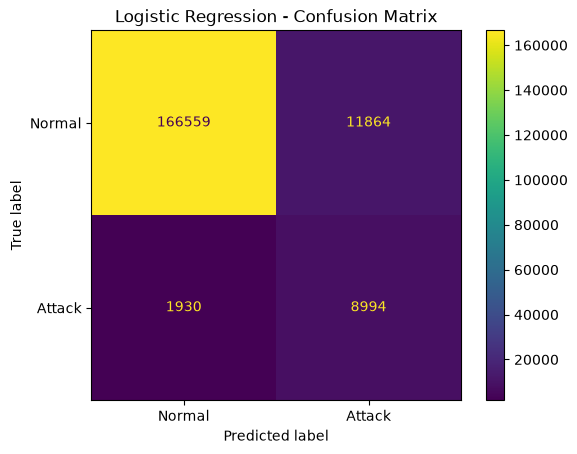

In [15]:
cm_lr = confusion_matrix(y_test, y_pred)

print("Logistic Regression:")
print(cm_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Normal", "Attack"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [16]:
## Baseline Model: Logistic Regression

#Logistic Regression was used as the baseline classification model for detecting cyber-attacks in the SWaT dataset.
#The model was trained using the training set and evaluated on the unseen test set. Because the dataset is highly imbalanced
#(approximately 96.21% Normal and 3.79% Attack), `class_weight="balanced"` was used to give more importance to the minority Attack
#class.

### Baseline Results

#| Metric    | Normal (0) | Attack (1) |
#|--------   |------------|------------|
#| Precision | 0.99       | 0.43       |
#| Recall    | 0.93       | 0.82       |
#| F1-score  | 0.96       | 0.57       |
#| Support   | 178,423    | 10,924     |

#Overall accuracy was 93%. However, accuracy is not considered the primary evaluation metric because of the significant
#class imbalance.

### Interpretation

#The baseline model achieved a Recall of 82% for the Attack class, meaning that it successfully detected most
#of the actual attacks in the test set. This is important for an intrusion/attack detection problem because missing an
#actual attack (False Negative) can be more costly than incorrectly flagging a normal observation.

#The Precision for the Attack class was 43%, indicating that less than half of the observations predicted as attacks
#were actually attacks. Consequently, the Attack F1-score was 0.57, showing that there is still room for improvement
#in balancing Precision and Recall.

#After removing duplicate records before splitting the data, the evaluation became more reliable and avoided the
#data leakage identified during the initial Random Forest experiment. The results therefore provide a cleaner and
#more defensible baseline for comparing subsequent models.

#These results provide a useful baseline for comparison. The main objective of the following experiments is to
#determine whether more powerful nonlinear models can improve the balance between Precision and Recall, particularly
#the F1-score for the minority Attack class, while maintaining a high Attack Recall.

### Baseline Conclusion

#Logistic Regression provides a reasonable starting point, detecting 82% of attacks with an Attack Precision of 43%
#and an F1-score of 0.57. Although the model performs reasonably well, there is still significant room for improvement,
#particularly in reducing false positives and improving the F1-score for the minority Attack class.

#Therefore, Random Forest and XGBoost will be evaluated next and compared against this baseline using Precision,
#Recall, F1-score, and other appropriate metrics rather than relying on accuracy alone.


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [18]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [19]:

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    178423
           1       0.98      1.00      0.99     10924

    accuracy                           1.00    189347
   macro avg       0.99      1.00      0.99    189347
weighted avg       1.00      1.00      1.00    189347



In [20]:
train_hash = pd.util.hash_pandas_object(X_train, index=False)
test_hash = pd.util.hash_pandas_object(X_test, index=False)

overlap = len(set(train_hash) & set(test_hash))

print("Duplicate rows shared between Train and Test:", overlap)

Duplicate rows shared between Train and Test: 5760


In [21]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

PIT501     0.092221
PIT503     0.078074
FIT503     0.076806
AIT402     0.069156
PIT502     0.064957
FIT401     0.059470
AIT501     0.053811
LIT301     0.045330
AIT502     0.045131
LIT401     0.042922
AIT202     0.033366
FIT504     0.032894
DPIT301    0.030599
FIT501     0.028665
LIT101     0.028354
dtype: float64


In [22]:
from sklearn.metrics import roc_auc_score

feature_auc = {}

for col in X_train.columns:
    try:
        score = roc_auc_score(y_train, X_train[col])
        feature_auc[col] = max(score, 1 - score)
    except:
        pass

feature_auc = pd.Series(feature_auc).sort_values(ascending=False)

print(feature_auc.head(15))

PIT503    0.885528
PIT501    0.878151
AIT501    0.863633
FIT503    0.859071
AIT504    0.832498
FIT301    0.825831
FIT504    0.820210
LIT401    0.808157
PIT502    0.807759
UV401     0.802012
P501      0.801886
MV304     0.800471
LIT301    0.793186
P402      0.790460
LIT101    0.785851
dtype: float64


In [ ]:
# Random Forest Results
#
# The Random Forest model achieved excellent performance on the test set.
# For the minority Attack class (1), the model achieved:
# Precision = 0.98, Recall = 1.00, and F1-score = 0.99.
#
# The model correctly detected 100% of the actual attacks in the test set,
# while maintaining a very high precision of 98%, indicating a low number
# of false positive predictions.
#
# Overall accuracy was 1.00. However, accuracy is not considered the primary
# evaluation metric because the dataset is highly imbalanced.
#
# Compared with the Logistic Regression baseline (Attack F1-score = 0.57),
# Random Forest showed a significant improvement in both Precision and F1-score
# for the Attack class.
#
# Duplicate records were removed before splitting the data, and additional
# feature-level checks were performed to investigate possible data leakage.
# No single feature showed an unusually high AUC close to 1.0.
#
# Although the Random Forest performance is very high, further validation
# and comparison with XGBoost and Neural Network models are required before
# selecting the final model.

In [24]:
print(df["Normal/Attack"].value_counts())

Normal/Attack
0    892112
1     54621
Name: count, dtype: int64


Random Forest:
[[178185    238]
 [    12  10912]]


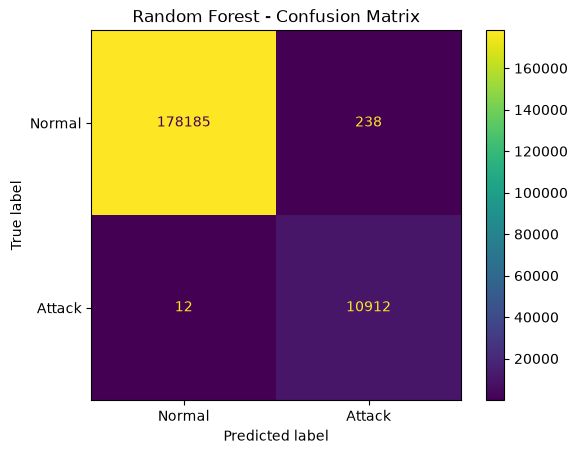

In [26]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Attack"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()